In [2]:
import os

DATA_DIR = None
for root, dirs, files in os.walk('/kaggle/input'):
    if os.path.basename(root) == 'color':
        DATA_DIR = root
        break

print("Color images folder:", DATA_DIR)
print("Number of class folders:", len(os.listdir(DATA_DIR)))

Color images folder: /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/plantvillage dataset/color
Number of class folders: 38


# **Build a table of all images**  

In [3]:
import pandas as pd

rows = []
for cls in sorted(os.listdir(DATA_DIR)):
    folder = os.path.join(DATA_DIR, cls)
    for f in os.listdir(folder):
        rows.append({"class": cls, "path": os.path.join(folder, f)})

df = pd.DataFrame(rows)
df["plant"] = df["class"].str.split("___").str[0]
df["disease"] = df["class"].str.split("___").str[1]
df["healthy"] = df["disease"].eq("healthy")

print("Total images:", len(df))
print("Classes:", df["class"].nunique(), "| Plants:", df["plant"].nunique())
df.head()

Total images: 54305
Classes: 38 | Plants: 14


,class,path,plant,disease,healthy
0,Apple___Apple_scab,/kaggle/input/datasets/abdallahalidev/plantvil...,Apple,Apple_scab,False
1,Apple___Apple_scab,/kaggle/input/datasets/abdallahalidev/plantvil...,Apple,Apple_scab,False
2,Apple___Apple_scab,/kaggle/input/datasets/abdallahalidev/plantvil...,Apple,Apple_scab,False
3,Apple___Apple_scab,/kaggle/input/datasets/abdallahalidev/plantvil...,Apple,Apple_scab,False
4,Apple___Apple_scab,/kaggle/input/datasets/abdallahalidev/plantvil...,Apple,Apple_scab,False


# **Images per class (key chart for the report)** 

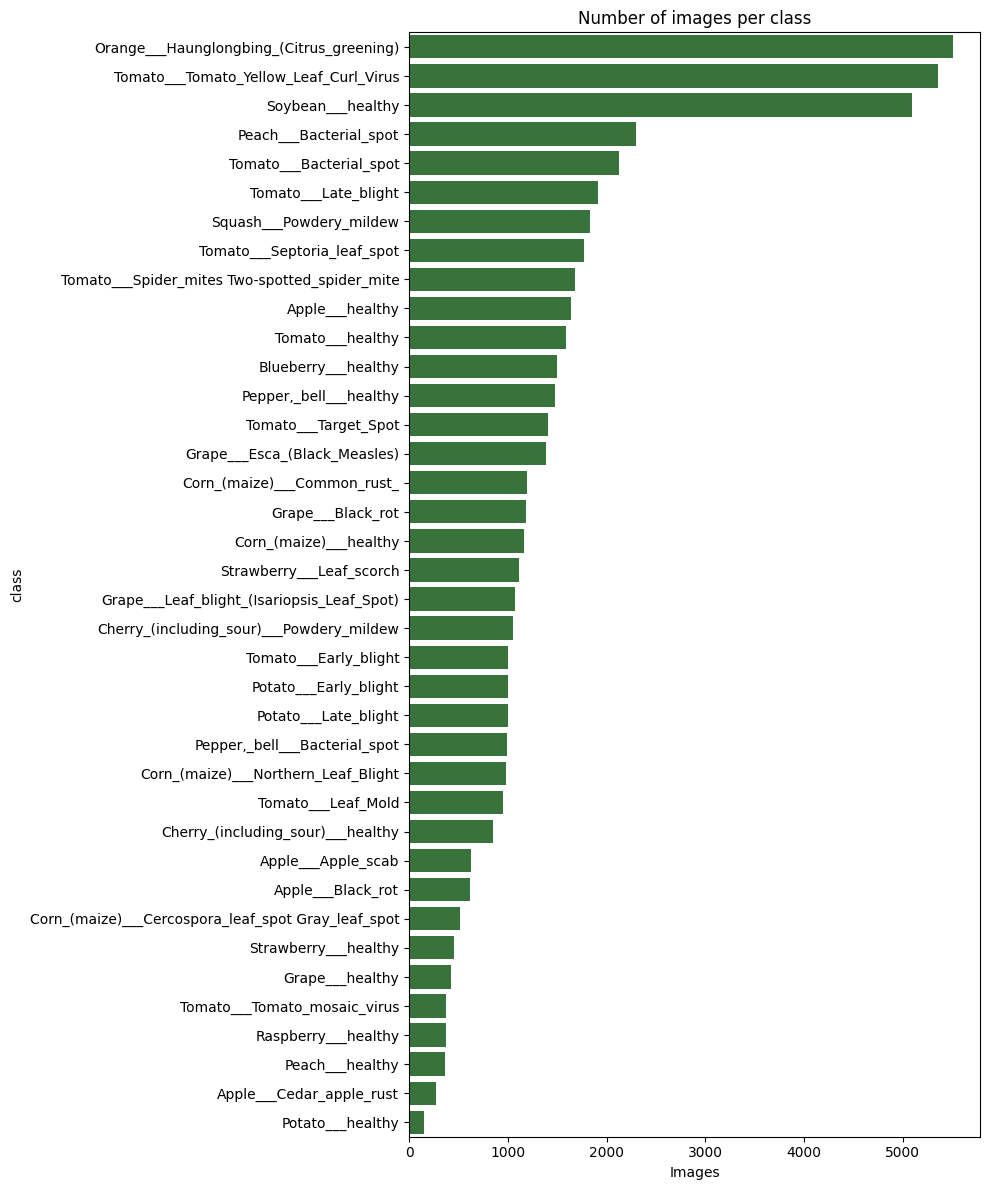

Largest class: Orange___Haunglongbing_(Citrus_greening) 5507
Smallest class: Potato___healthy 152
Imbalance ratio: 36.2


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("/kaggle/working/figures", exist_ok=True)

counts = df["class"].value_counts()
plt.figure(figsize=(10, 12))
sns.barplot(x=counts.values, y=counts.index, color="#2E7D32")
plt.title("Number of images per class")
plt.xlabel("Images")
plt.tight_layout()
plt.savefig("/kaggle/working/figures/images_per_class.png", dpi=150)
plt.show()

print("Largest class:", counts.idxmax(), counts.max())
print("Smallest class:", counts.idxmin(), counts.min())
print("Imbalance ratio:", round(counts.max() / counts.min(), 1))

# **Images per plant, healthy vs diseased**

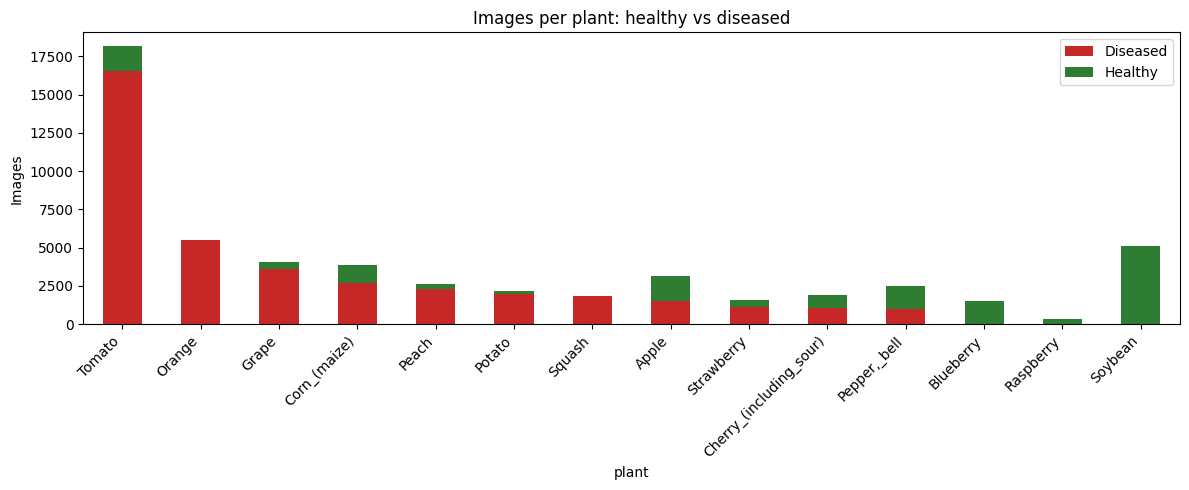

,Diseased,Healthy
plant,,
Tomato,16569,1591
Orange,5507,0
Grape,3639,423
Corn_(maize),2690,1162
Peach,2297,360
Potato,2000,152
Squash,1835,0
Apple,1526,1645
Strawberry,1109,456


In [5]:
plant_stats = df.groupby(["plant", "healthy"]).size().unstack(fill_value=0)
plant_stats.columns = ["Diseased", "Healthy"]
plant_stats = plant_stats.sort_values("Diseased", ascending=False)

plant_stats.plot(kind="bar", stacked=True, figsize=(12, 5), color=["#C62828", "#2E7D32"])
plt.title("Images per plant: healthy vs diseased")
plt.ylabel("Images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("/kaggle/working/figures/healthy_vs_diseased.png", dpi=150)
plt.show()
plant_stats

# **Show one example per class**

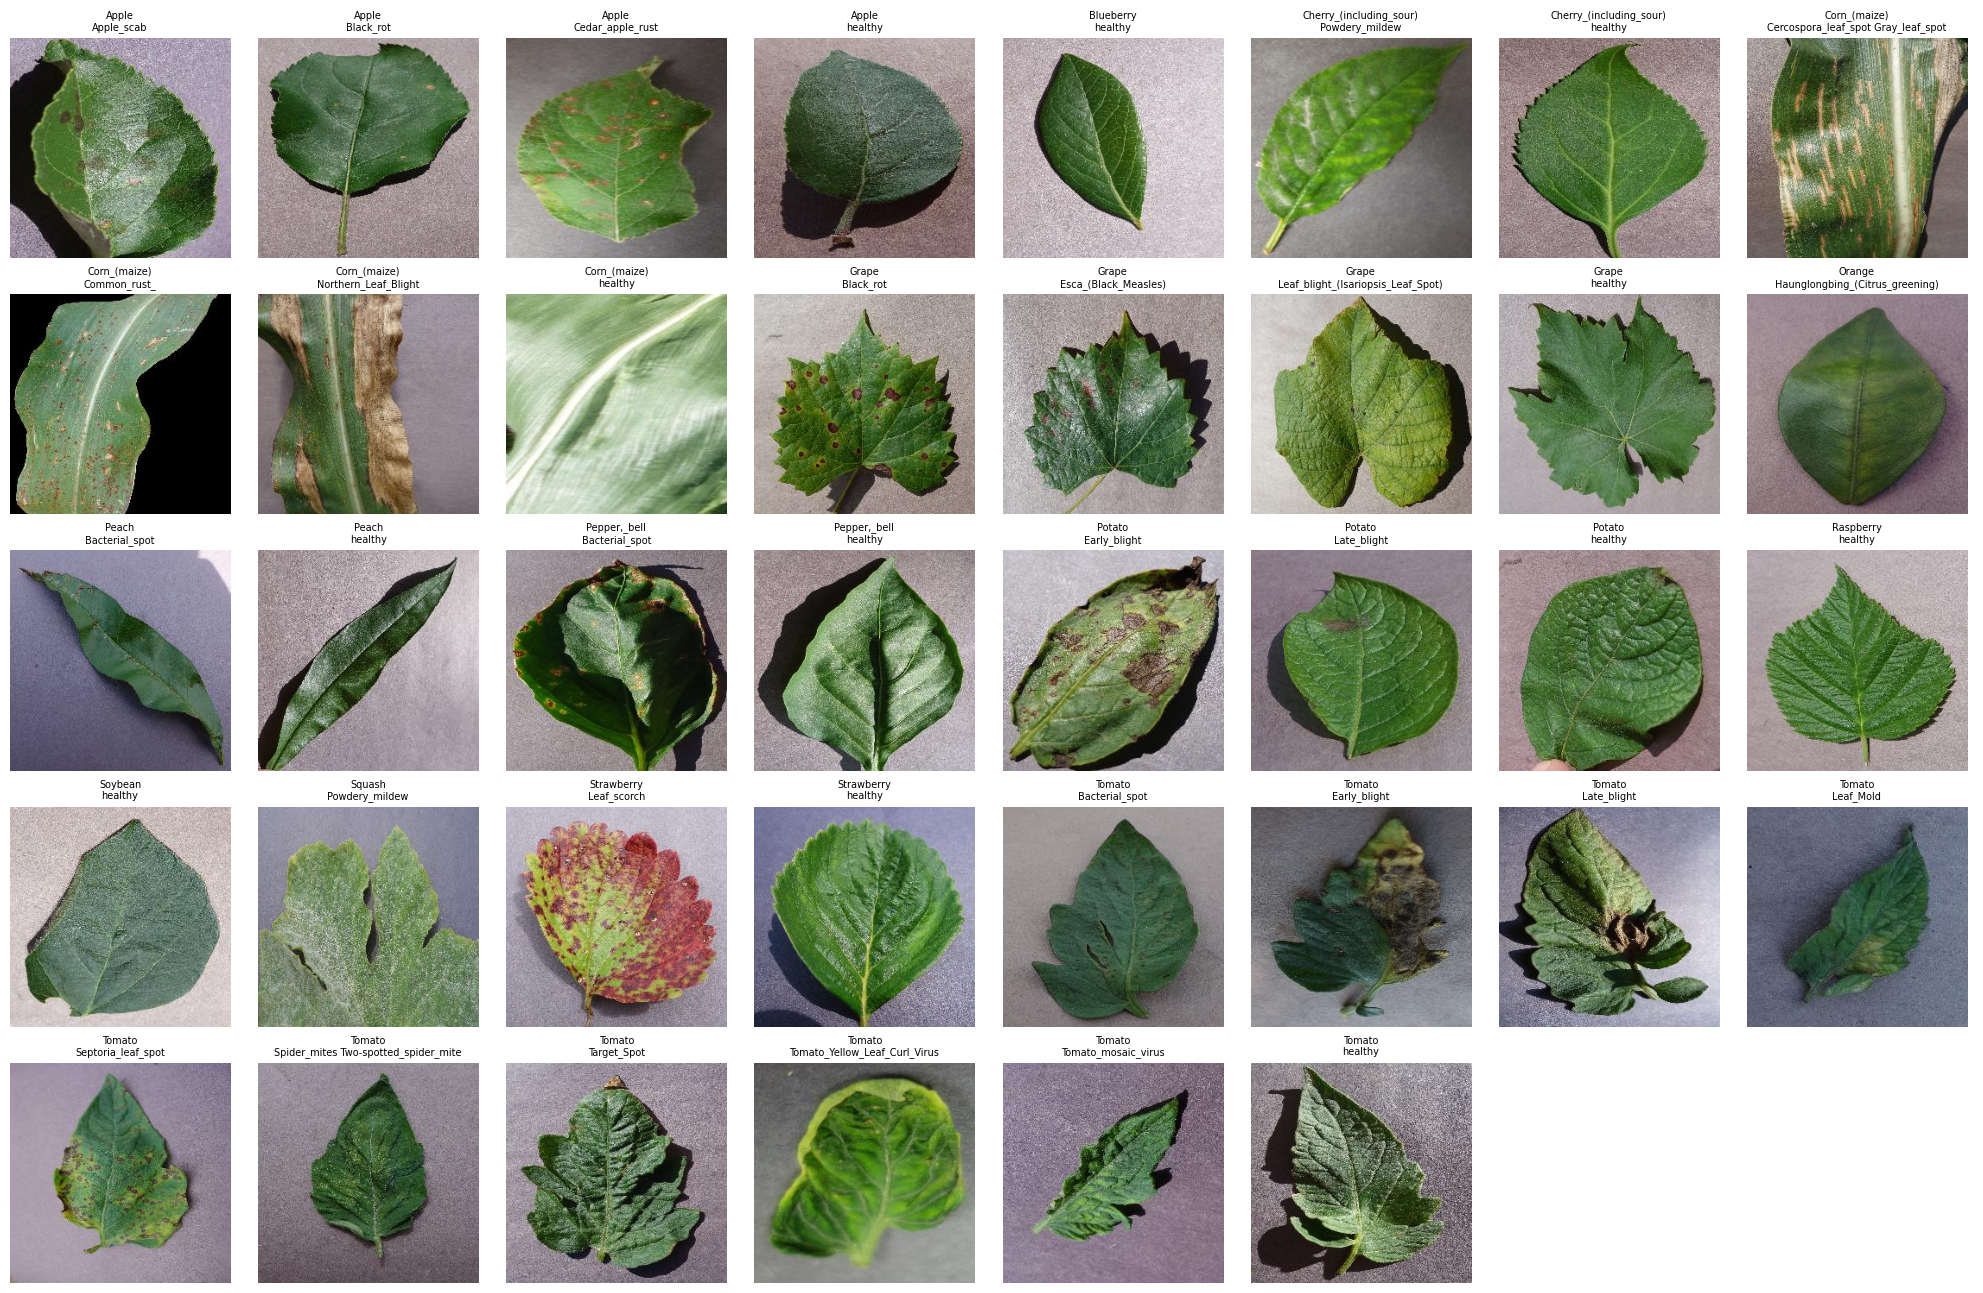

In [6]:
from PIL import Image

classes = sorted(df["class"].unique())
fig, axes = plt.subplots(5, 8, figsize=(20, 13))
for ax in axes.flat:
    ax.axis("off")
for ax, cls in zip(axes.flat, classes):
    img_path = df[df["class"] == cls]["path"].iloc[0]
    ax.imshow(Image.open(img_path))
    ax.set_title(cls.replace("___", "\n"), fontsize=7)
plt.tight_layout()
plt.savefig("/kaggle/working/figures/samples_per_class.png", dpi=120)
plt.show()

# **Check image sizes**

In [7]:
sample = df.sample(500, random_state=42)
sizes = sample["path"].apply(lambda p: Image.open(p).size)
print(sizes.value_counts())

#e'll resize them to 224×224, the input size MobileNetV2 expects.

path
(256, 256)    500
Name: count, dtype: int64


# **Create and save the train/validation/test split**

In [8]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df["class"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["class"], random_state=42)

train_df.to_csv("/kaggle/working/train_split.csv", index=False)
val_df.to_csv("/kaggle/working/val_split.csv", index=False)
test_df.to_csv("/kaggle/working/test_split.csv", index=False)

print(f"Train: {len(train_df)} | Validation: {len(val_df)} | Test: {len(test_df)}")

#This gives a 70% / 15% / 15% split.
#Stratified means each class keeps the same proportion in all three sets.
#random_state=42 makes the split reproducible.
#The test set won't be touched until the final evaluation

Train: 38013 | Validation: 8146 | Test: 8146
